---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.29 (Support Vector Machines Part-II)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

# Learning agenda of this notebook

**Section I: (Soft Margin SVM)** 
- Recap of Hard Margin SVM
- Issues with Hard Margin SVM
- Soft Margin SVM
    - Math Behind Soft Margin SVM
    - Python Implementation: (Soft Margin SVM)
        - Perfectly Linearly Separable Dataset
        - Almost Linearly Separable Dataset
        - What about Not Linearly Separable Dataset?


**Section II: (Kernel Trick in SVM)**
- Handling Non Linear Data
- Mapping Non-Linear data to higher dimensions
- SVM Kernel Functions and its Types
    - `Linear Kernel`
    - `Polynomial Kernel`
    - `Radial Basis Function (RBF) Kernel`
    - `Sigmoid Kernel`
    - Laplace RBF Kernel
    - Hyperbolic Tangent Kernel
    - Bessel Function Kernel
    - Anova RBF Kernel
    - Linear Spline Kernel
- Python Implementation
   - Linear Kernel
   - Polynomial Kernel
   - RBF Kernel
- Tasks to Do

# <span style='background :lightgreen' > Section I: (Soft Margin SVM) </span>

<img align="right" width="450" src="images/svm8b.png"  > 

# 1. Recap of Hard Margin SVM
- General Rule to Classify a New Data Point:
<font face = "Courier New" color=black size=4>
$$
\large \hat y_i = 
\Bigg\{
\begin{matrix}
+1, & \text{if}& \overrightarrow{w}\overrightarrow{x_i}+b\ge 0 \\
-1, & \text{if} & \overrightarrow{w}\overrightarrow{x_i}+b\lt 0  \\
\end{matrix}
$$
</font>
<br><br>
- **Constraint for Hard SVM:** 
    - We need to maximize the margin, such that 
        - NO training point is `below` the `Positive Hyperplane`: <font face = "Courier New" color=green size=3>$\large \hspace{2cm}  \overrightarrow{ w}  \overrightarrow{ x}  + b \ge 1$</font>
        - NO training point is `above` the `Negative Hyperplane`: <font face = "Courier New" color=blue size=3>$\large \hspace{2cm}  \overrightarrow{ w}  \overrightarrow{ x}  + b \lt -1$</font>
    - Simplify the above two equation to one, assuming that the label of all the positive training points is $+1$ and the label of all the negative training points is $-1$:<br><br>
<font face = "Courier New" color=magenta size=5>$$ y_i(\overrightarrow{w}  \overrightarrow{x_i}  + b) \ge 1$$</font>

<font face = "Courier New" color=purple size=5>
$\hspace{5cm} \large argmax_{(w^*, b^*)} \hspace{0.5cm} \frac{2}{\lVert w \rVert} $
</font>

<font face = "Courier New" color=purple size=5>
$\hspace{5cm}\large argmax_{(w^*, b^*)} \hspace{0.5cm} \frac{1}{\lVert w \rVert}$
</font>

<font face = "Courier New" color=purple size=5>
$\hspace{5 cm}\large argmin_{(w^*, b^*)} \hspace{0.5cm}\lVert w \rVert $
</font>

<font face = "Courier New" color=purple size=5>
$\hspace{4cm}\large argmin_{(w^*, b^*)} \hspace{0.5cm} \frac{1}{2}\large \lVert w \rVert^2, \hspace{1 cm} \text{such that} \hspace{1 cm} y_i(\overrightarrow{w} \overrightarrow{x_i}  + b) \ge 1 $
</font>

### 100\$ Question:

<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">How to find the values of $\overrightarrow{w}$ and $b$ for the best decision boundry that maximizes the distance between the positive and negative hyperplanes?</h3>

<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">One of the way to solve the above constraint optimisation problem is to add one more variable (called Lagrange multiplier) for each constraint and solve it.</h3>

## Langrange Multipliers:
- In mathematical optimization, the method of Lagrange multipliers is a strategy for finding the local maxima and minima of a function subject to equation constraints (i.e., subject to the condition that one or more equations have to be satisfied exactly by the chosen values of the variables). It is named after the mathematician Joseph-Louis Lagrange.
- In the general case, for two functions $f(x)$ and $g(x)$ and Lagrange multiplier ($\large \alpha$ or $\large \lambda$), the Langrangian function is defined as:

<font face = "Courier New" color=green size=6>
$$\hspace{1 cm}L(x,\alpha) = f(x) + \alpha . g(x)$$
</font>

- Where, $\large \lambda$ or $\large \alpha$ is called the Langrange multiplier
<br><br>

- So the above function with constraint can be written as a Langrangian function as shown below:
<font face = "Courier New" color=green size=6>
$$\hspace{1 cm}L = \frac{1}{2}  \lVert w \rVert^2 - \sum \alpha_i [y_i (\overrightarrow{w} \overrightarrow{x_i}+b)-1]$$
</font>

- In order to find the minimum of a constrained function all partial derivatives should be zero.
<img align="center" width="600" src="images/langrange1.png"  > 
<br><br>

- Plug in the value of $\overrightarrow{w}$ in above Loss function, shown in green:
<br><br>
<font face = "Courier New" color=black size=5>
$$\hspace{1 cm}L = \frac{1}{2} \large(\small \sum \alpha_i y_i x_i\large).(\small \sum \alpha_i y_i x_i\large)\hspace{0.3cm}-\hspace{0.3cm} (\small \sum \alpha_i y_i x_i\large).(\small \sum \alpha_j y_j x_j\large) \hspace{0.3cm}-\hspace{0.3cm} b\small \sum \alpha_iy_i + \small \sum \alpha_i$$
</font>

<font face = "Courier New" color=green size=6>
$$\hspace{1 cm}L = \sum \alpha_i - \frac{1}{2} \small \sum \sum \alpha_i \alpha_j y_i y_j x_i.x_j$$
</font>

# 2. Soft Margin SVM

- The **hard margin** is the decision boundary that maximizes the margin and separates the classes perfectly. Note in the left image there is on training data point that is there on the wrong side of the decision boundry and even inside the margin. This works well when the data is perfectly linearly separable by using the constraint $y_i(\overrightarrow{w} \overrightarrow{x_i}  + b) \ge 1$. However, in case of outliers and noise in the data as shown in the right image this constraint will not work.<br>
    - <font face = "Garamond" color=blue size=3>**Option 1:** Change the decision boundry so that we correctly classify all the data points at the cost of a smaller margin. (Not possible in case of dataset shown in right image)</font>
    - <font face = "Garamond" color=blue size=3>**Option 2:** Use Soft Margin SVM by relaxing the constraint and allowing few data points to be inside the margin and  even on the wrong side of the decision boundry</font>

- The **soft margin** allows for some misclassification of the data points in order to maximize the margin. This is useful when the data is not linearly separable and there are some outliers or noise in the data. This is done by allowing few data points to be inside the margin and even on the wrong side of the decision boundry

<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">In <b>Soft Margin</b> we allow SVM to make a certain number of mistakes and keep margin as wide as possible so that other points can still be classified correctly. </font></center>


<img align="center" width="750" src="images/softsvm.png"  > 
<br>

<font face = "Garamond" color=purple size=4>**Hard Margin SVM:**</font>

<font face = "Courier New" color=purple size=5>
$\hspace{2cm}\large argmin_{(w^*, b^*)} \hspace{0.5cm} \frac{1}{2}\large \lVert w \rVert^2, \hspace{4.2 cm} \text{such that} \hspace{1 cm} y_i(\overrightarrow{w} \overrightarrow{x_i}  + b) \ge 1 $
</font>
<br><br><br><br>

<font face = "Garamond" color=blue size=4>**Soft Margin SVM:**</font>    

<font face = "Courier New" color=blue size=5>
$\hspace{2cm}\large argmin_{(w^*, b^*)} \hspace{0.5cm} \frac{1}{2}\large \lVert w \rVert^2 + C \sum \zeta_i, \hspace{1 cm} \text{such that} \hspace{1 cm} y_i(\overrightarrow{w} \overrightarrow{x_i}  + b) \ge 1 - \zeta_i$ 
</font>

<br><br>
>- <font face = "Garamond" color=blue size=3>**Minimizing the first term will maximize the margin, while minimizing the second term will minimize the error**</font>

## Langrange Multipliers:
<br><br>
<font face = "Garamond" color=purple size=4>**Loss/Objective Function for Hard Margin SVM:**</font>

<font face = "Courier New" color=purple size=6>
$$\hspace{1 cm}L = \frac{1}{2}  \lVert w \rVert^2 - \sum \alpha_i [y_i (\overrightarrow{w} \overrightarrow{x_i}+b)-1]$$
</font>
<br><br>

<font face = "Garamond" color=blue size=4>**Loss/Objective Function for Hard Margin SVM:**</font>

<font face = "Courier New" color=blue size=6>
$$\hspace{1 cm}L = \frac{1}{2}  \lVert w \rVert^2 + C \sum \zeta_i - \sum \alpha_i [y_i (\overrightarrow{w} \overrightarrow{x_i}+b)-1 + \zeta_i]$$
</font>

## $\zeta_i$:
- For every data point $x_i$, we introduce a slack variable $\zeta_i$. The value of $\zeta_i$ is the distance of $x_i$ from the corresponding class’s margin if $x_i$ is on the wrong side of the margin, otherwise zero. 
- For all `positive` data points `above` the `positive hyperplane`, and for all `negative` data points `below` the `negative hyperplane`, the $\zeta$ value will be zero.
- For a `positive` data point `below` the `decision boundry` the corresponding $\zeta$ value will be greater than 1, and for a `positive` data point that is on the correct side of the decision boundry, but within the margin will have a $\zeta$ value between 0 and 1.
- For a `negative` data point above the decision boundry the corresponding $\zeta$ value will be greater than 1, and for a `negative` data point that is on the correct side of the decision boundry, but within the margin will have a $\zeta$ value between 0 and 1.
- Thus the points that are far away from the margin on the wrong side would get more penalty.

## C:
- The regularization hyperparameter `C` controls the `trade-off` between `maximizing the margin` and `minimizing the misclassification`.
- A `very small value of C`, makes the second term of above expression small, thus the model will ignore classification errors and will `focus on increasing the margin`.
- A `large value of C`, makes the second term of above expression large, thus the model  will not concentrate on maximizing the margin, rather will `focus on reducing the number of miss-classified points`.
- By setting the value of hyperparameter $C = +\infty$, we will get the same result as hard margin SVM.

# 3. Implementation of Soft Margin Support Vector Classifier

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# User defined plotting function
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

## a. Perfectly Linearly Separable Dataset

Shape of X array:  (50, 2)
Shape of y array:  (50,)


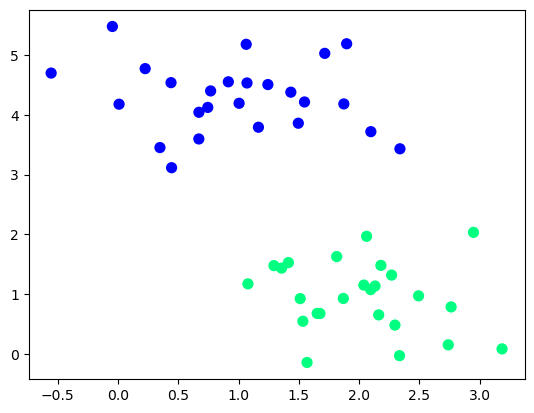

In [2]:
from sklearn import datasets
# make_blobs() method is used to generate isotropic Gaussian blobs for clustering.
# returns a tuple of two ndarrays 
# X containing generated samples of shape (n_samples, n_features)
# y containing the integer labels for cluster membership of each sample

X, y = datasets.make_blobs(n_samples=50,    # total number of points equally divided among clusters.
                           n_features=2,    # number of features for each sample
                           centers=2,       # number of centers to generate
                           cluster_std=0.6, # standard deviation of the clusters.
                           random_state=0)  # for reproducible output across multiple function calls

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter');
print("Shape of X array: ",X.shape)
print("Shape of y array: ",y.shape)

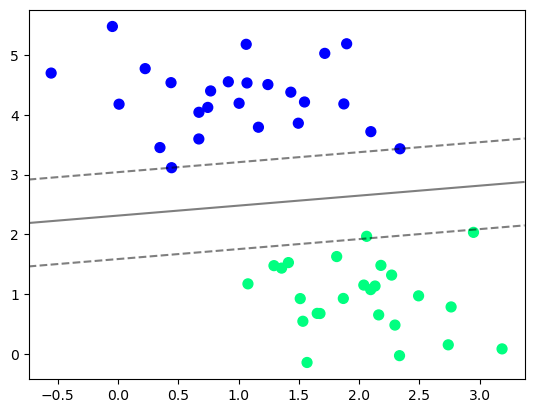

In [5]:
from sklearn.svm import SVC 

model = SVC(kernel='linear', C=1) 
#model = SVC(kernel='linear', C=0.1)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model);

## b. Almost Linearly Separable Dataset

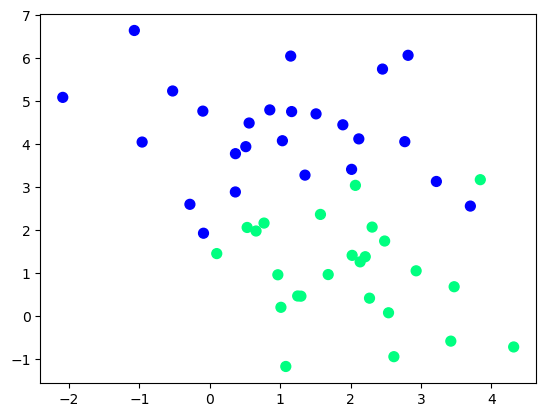

In [6]:
# Generate another dataset that is not perfectly linearly separable by increasing the cluster_std from 0.6 to 1.2
X, y = datasets.make_blobs(n_samples=50, 
                           n_features=2, 
                           centers=2, 
                           cluster_std=1.2,
                           random_state=0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter');

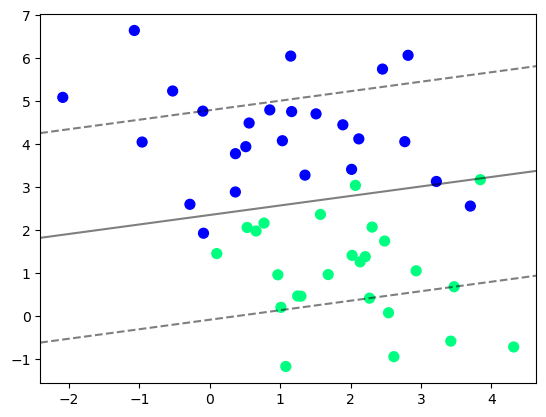

In [7]:
# With a small value of C, the model will ignore classification errors and will focus on increasing the margin.
model = SVC(kernel='linear', C=0.01)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model);

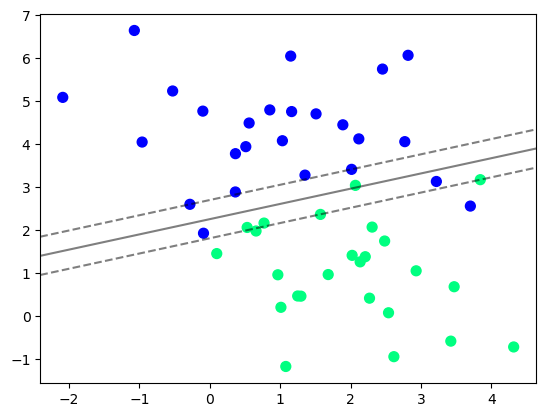

In [9]:
# With a large value of C, the model will not concentrate on maximizing the margin, 
# rather will focus on reducing the number of miss-classified points.
model = SVC(kernel='linear', C=1000)
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model);

## c. What about Not Linearly Separable Dataset?

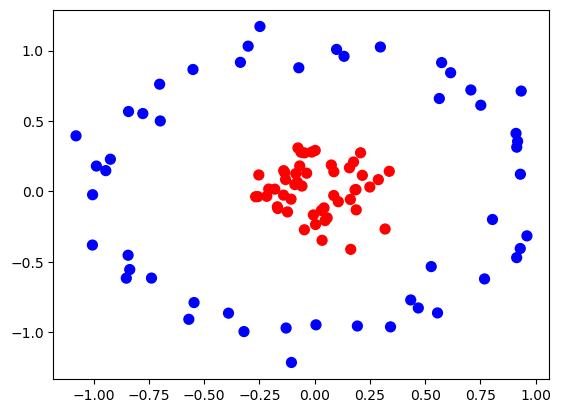

In [10]:
from sklearn import datasets
# make_circles() method is used to make a large circle containing a smaller circle in 2d.
# Generate is synthetic dataset to visualize clustering and classification algorithms.
# returns a tuple of two ndarrays 
# X containing generated samples of shape (n_samples, 2)
# y containing the integer labels (0 or 1) for class membership of each sample

X, y = datasets.make_circles(n_samples=100, # total number of data points generated
                             factor=.2,     # Scale factor between inner and outer circle in the range `(0, 1)`
                             noise=.1,      # Standard deviation of Gaussian noise added to the data.
                             random_state=54) # for reproducability

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr');

>- Above data is not linearly separable, as there is no straight or even curvy line that can separate the two classes of this data set.
>- We have to draw a circle to classify the two classes of this data set.
>- If you observe the above scatter chart, it is quite clear that this data is non-linearly separable, not because of the presence of outliers or noise in it, rather this data is characteristically non-linearly separable

# <span style='background :lightgreen' > Section II: (Kernel Trick in SVM) </span>

# 1. Classifying Non-Linear Data using SVM

## a. Linearly vs Non-Linearly Separable Data
- **Linear SVM:** When the data is perfectly linearly separable only then we can use Linear SVM. Perfectly linearly separable means that the data points can be classified into 2 classes by using a single straight line(if 2D).
- **Non-Linear SVM:** When the data is not linearly separable then we can use Non-Linear SVM, which means when the data points cannot be separated into 2 classes by using a straight line (if 2D) then we use some advanced techniques like kernel tricks to classify them. In most real-world applications we do not find linearly separable datapoints hence we use kernel trick to solve them.    
<img align="center" width="1000" src="images/ksvm0.png"  > 

## b. Approach 1: Adding more features to make the Data Linearly Separable

## (i) Mapping a 1D Dataset to 2D to make it Linearly Separable

<img align="center" width="1000" src="images/ksvm1.png"  > 

<img align="center" width="1500" src="images/ksvm2.png"  > 

>- In 1-dimension, this data is not linearly separable, but after applying the transformation ϕ(x) = x² and adding this second dimension to our feature space, the classes become linearly separable.

<img align="center" width="1500" src="images/ksvm3.png"  > 

## (ii) Mapping a 2D dataset to 3D to make it Linearly Separable

<img align="center" width="900" src="images/ksvm4.png"  > 
<br><br>
<font face = "Garamond" color=black size=4> 
$\hspace{3cm} (1, 2)$ will be mapped to $(1, 2\sqrt2, 4)\hspace{1cm}$ and 
$\hspace{1cm} (3, 4)$ will be mapped to $(9, 12\sqrt2, 16)$
</font>

<font face = "Garamond" color=red size=4>**Limitations of Approach 1:** <font face = "Garamond" color=purple size=4>(Transforming dataset to a higher. dimension, applying SVC, and then going back to lower dimension)<br>
<font face = "Garamond" color=red size=3>**1. We need to choose what non-linear transformation should be applied to a data set?**</font><br>
<font face = "Garamond" color=red size=3>**2. If we want a sophisticated decision boundry, we may need to increase the dimensions of the transformations, which in turn increases computational requirements specially for large datasets.**
    
<font face = "Garamond" color=green size=4>**SVM gives a solution to this, and that is Kernel Trick, which allows us to operate on the original feature space without computing the coordinate of the data in the higher dimensional space**     
</font>

# 2. Approach 2: Using Kernel Trick to make the Data Linearly Separable

<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">A kernel function is a mathematical function that takes as its inputs, vectors in the original space (lower dimensional), and return the dot product of the transformed vectors in the feature space (higher dimensional).</h3>
    
- `Linear Kernel`
- `Polynomial Kernel`
- `Radial Basis Function (RBF) Kernel`
- `Sigmoid Kernel`
- Laplace RBF Kernel
- Hyperbolic Tangent Kernel
- Bessel Function Kernel
- Anova RBF Kernel
- Linear Spline Kernel

## a. Linear Kernel

- The most simplest of all is Linear Kernel, usually one dimensional in nature.

<font face = "Courier New" color=magenta size=6>
$\hspace{3cm} K(\overrightarrow{x_1}, \overrightarrow{x_2}) \hspace{0.5cm}=\hspace{0.5cm} \phi(\overrightarrow{x_1}).\phi(\overrightarrow{x_2}) \hspace{0.5cm}=\hspace{0.5cm} \overrightarrow{x_1}^T . \overrightarrow{x_2}$
</font>

- It proves to be the best function when there are lots of features and the data is linearly separable. The linear kernel is mostly preferred for text-classification problems as most of these kinds of classification problems can be linearly separated.

## b. Polynomial Kernel
- Polynomial Kernel is the generalized form of Linear Kernel, and its formula is shown below (which is equivalent to Linear Kernel if $c=0$ and $d=1$):
<font face = "Courier New" color=magenta size=6>
$\hspace{5cm}K(\overrightarrow{x_1}, \overrightarrow{x_2}) \hspace{0.5cm}=\hspace{0.5cm} (\overrightarrow{x_1^T} . \overrightarrow{x_2} + c)^d$
</font>

    - Where `c` is a constant. A zero value of `c` means homogeneous kernel, and when `c` is set to a non-zero value then it is called inhomogeneous kernel.
    - where `d` is a hyperparameter that specifies the degree of the polynomial. If `d =  2`, it is called quadratic kernel. A higher value of `d` may lead to overfitting, i.e., classification works fine on the training data, but gives bad results on test data.  

### Example:
<img align="center" width="1000" src="images/ksvm5a.png"  > 

<br>

**Use Approach 1 (Adding more features to make the Data Linearly Separable using a Mapping Function):**
- Apply above polynomial mapping function to a 2-D data point to get a 3-D data point: $\hspace{1cm} \phi(1,2) = (1, 2\sqrt2, 4)$
- Apply above polynomial mapping function to a 2-D data point to get a 3-D data point: $\hspace{1cm} \phi(3,4) = (9, 12\sqrt2, 16)$
- Take dot product: $\hspace{1cm} \phi(1,2) . \phi(3,4) = (1, 2\sqrt2, 4).(9, 12\sqrt2, 16) = (1*9+2\sqrt2*12\sqrt2+4*16 = 121$
    
<br><br>
**Use Approach 2 (Use Kernel Trick):**
- $\large K(a,b) \hspace{0.5cm}=\hspace{0.5cm} (a^T.b)^2 \hspace{0.5cm}=\hspace{0.5cm} \left( \begin{bmatrix} 1 \\ 2  \end{bmatrix}.\begin{bmatrix} 3 & 4  \end{bmatrix}\right)^2\hspace{0.5cm}=\hspace{0.5cm} (1*3+2*4)^2\hspace{0.5cm}=\hspace{0.5cm}121$

<font face = "Garamond" color=green size=3>We have achieved the same result (i.e., 121) by using a polynomial kernel of degree 2, but with far less computation. </font>

#### Following Matrix Algebra proves that if you apply the above polynomial function on both vectors a and b, and then take their dot product (computationally expensive) is the same as taking the dot product of the two vectors and then taking their square (less expensive)

<img align="center" width="800" src="images/ksvm5b.png"  > 

**Sample Problem:** Consider two data points $x_1 = (1,2)$ and $x_2 = (2,3)$ with $c=1$. Calculate the value using the following kernels:
- Linear Kernel
- Quadratic Homogeneous Kernel
- Quadratic In-homogeneous Kernel

## c. Radial Basis Function (RBF) Kernel 
- The Gaussian Radial Basis Function is the most commonly used Kernel in SVM.
- $K(\overrightarrow{x}, \overrightarrow{l^i})$ is the Kernel function, with $x$ as the input vector and  $\overrightarrow{l^i}$ as the landmark point. 
- The RBF Kernel formula is shown below:


<font face = "Courier New" color=magenta size=6>
$\hspace{6cm}K(\overrightarrow{x}, \overrightarrow{l^i}) \hspace{0.5cm}=\hspace{0.5cm} e^{- \gamma \lVert x-l^i \rVert ^2} \hspace{0.5cm}=\hspace{0.5cm} e^{-\frac{\lVert x-l^i \rVert ^2}{2\sigma^2}}$
</font>
<br>



- Consider the following scatter chart of a dataset, with the blue circle showing the landmark point.
- The data points that are close to  this landmark point will have a smaller Euclidean distance $\lVert x-l^i \rVert ^2$, and in turn will have a large Kernel value. The maximum value of an RBF Kernel can be 1 and that occur when the Euclidean distance is zero (same points).
- The data points that are far away from  this landmark point will have a larger Euclidean distance $\lVert x-l^i \rVert ^2$, and in turn will have a small Kernel value. The minimum value of an RBF Kernel can be zero and that occur when the Euclidean distance is very large.


<img align="center" width="800" src="images/ksvm7a.png"  > 
<br>

- **Example 1:** Consider two data points $x_1 = (1,2)$ and $l = (1,2)$ with $\sigma=1$. Calculate the value of RBF kernel
$\hspace{3cm}K(x_1, x_2) \hspace{0.5cm} =\hspace{0.5cm}  \large e^{- \gamma \lVert x-l^i \rVert ^2} \hspace{0.5cm}\small=\hspace{0.5cm} \large e^{-\frac{\lVert x-l^i \rVert ^2}{2\sigma^2}} \hspace{0.5cm}\small =\hspace{0.5cm}  \large e^{-\frac{(1-1)^2 + (2-2)^2)}{2*1^2}}\hspace{0.5cm}\small =\hspace{0.5cm} \large e^0 \hspace{0.5cm}\small =\hspace{0.5cm} 1.0$
<br><br>

- **Example 2:** Consider two data points $x_1 = (1,2)$ and $l = (2,3)$ with $\sigma=1$. Calculate the value of RBF kernel
$\hspace{3cm}K(x_1, x_2) \hspace{0.5cm}=\hspace{0.5cm}    \large e^{- \gamma \lVert x-l^i \rVert ^2} \hspace{0.5cm}\small=\hspace{0.5cm} \large e^{-\frac{\lVert x-l^i \rVert ^2}{2\sigma^2}} \hspace{0.5cm}\small =\hspace{0.5cm}   \large e^{-\frac{(2-1)^2 + (3-2)^2)}{2*1^2}}\hspace{0.5cm}\small =\hspace{0.5cm} \large e^{-1} \hspace{0.5cm}\small =\hspace{0.5cm} 0.368$

<br>

- The points that are close to the landmark point falls along the peak in the right mesh grid having RBF values greater than zero and close to one. The 3-D data shown in the right mesh grid has now become linearly separable.

- In the RBF formula, $\gamma$ is a hyperparameter whose value is normally equal to $\large \frac{1}{2\sigma^2}$

- A large value of $\gamma$ or a small value of $\sigma$, will raise the peak of the curve and the data points that are very close to the landmark point will be considered similar. 

- A small value of $\gamma$ or a large value of $\sigma$, will lower/flatten the peak of the curve and the data points that are even far away from the landmark point will also be considered similar. 
<br>

# 3. Implementation of Kernel Trick in SVM

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [12]:
# make_circles() method is used to make a large circle containing a smaller circle in 2D.
# Generate is synthetic dataset to visualize clustering and classification algorithms.
# returns a tuple of two ndarrays 
# X containing generated samples of shape (n_samples, 2)
# y containing the integer labels (0 or 1) for class membership of each sample

X, y = datasets.make_circles(n_samples=100, # total number of data points generated
                             factor=0.4,    # Scale factor between inner and outer circle in the range `(0, 1)`
                             noise=.2,      # Standard deviation of Gaussian noise added to the data.
                             random_state=54) # for reproducability

df = pd.DataFrame(dict(x1=X[:, 0], x2=X[:, 1], y=y))
df

,x1,x2,y
0,-0.070628,-0.955298,0
1,-0.114435,0.077069,1
2,0.952296,-0.381005,0
3,0.008264,-0.468202,1
4,-0.281060,-0.051566,1
...,...,...,...
95,-0.026076,0.559787,1
96,-0.879248,0.209111,0
97,-0.292361,1.111181,0
98,0.853666,0.575727,0


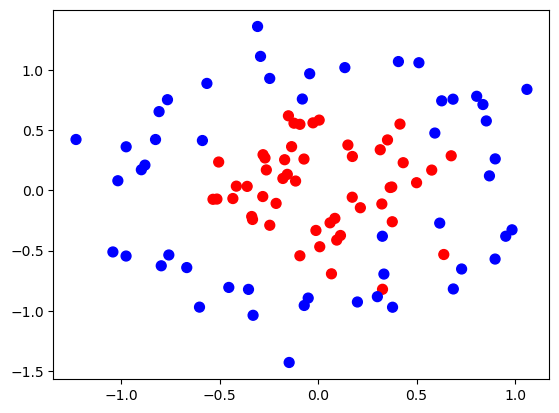

In [13]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr');

## a. SVC Linear Kernel
<font face = "Courier New" color=magenta size=5>
$\hspace{3cm} K(\overrightarrow{x_1}, \overrightarrow{x_2}) \hspace{0.5cm}=\hspace{0.5cm} \phi(\overrightarrow{x_1}).\phi(\overrightarrow{x_2}) \hspace{0.5cm}=\hspace{0.5cm} \overrightarrow{x_1}^T . \overrightarrow{x_2}$
</font>

**Train the Model, Predict and Evaluate** 

Accuracy score:  0.58
F1 score:  0.631578947368421


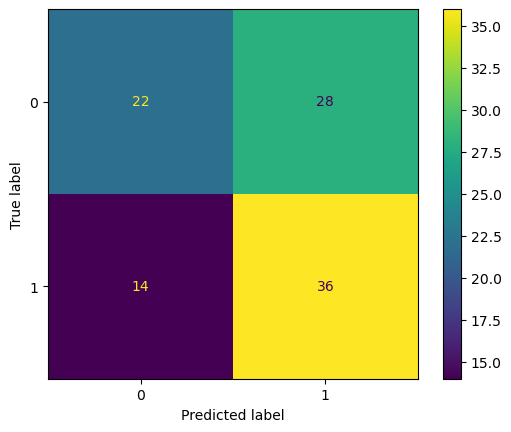

In [14]:
model = SVC(kernel='linear')
model.fit(X, y)
y_pred = model.predict(X)
print("Accuracy score: ", accuracy_score(y, y_pred))
print("F1 score: ", f1_score(y, y_pred))
ConfusionMatrixDisplay.from_predictions(y, y_pred);

**Plot Decision Boundry for Visualizing Results** 

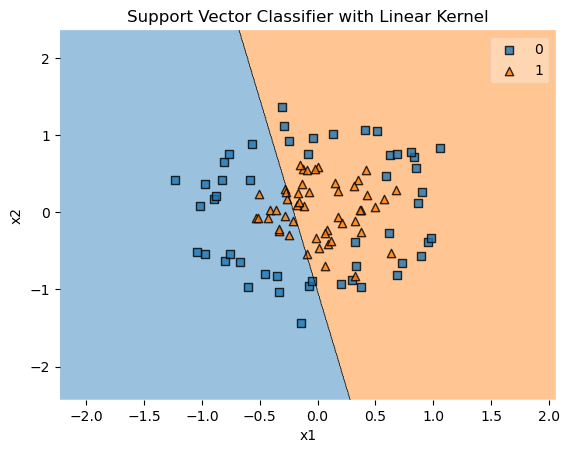

In [15]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X=X, y=y, clf=model)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Support Vector Classifier with Linear Kernel')
plt.show();

## b. SVC Polynomial Kernel
<font face = "Courier New" color=magenta size=5>
$\hspace{5cm}K(\overrightarrow{x_1}, \overrightarrow{x_2}) \hspace{0.5cm}=\hspace{0.5cm} (\overrightarrow{x_1^T} . \overrightarrow{x_2} + c)^d$
</font>


**Train the Model, Predict and Evaluate** 

Accuracy score:  0.93
F1 score:  0.9320388349514563


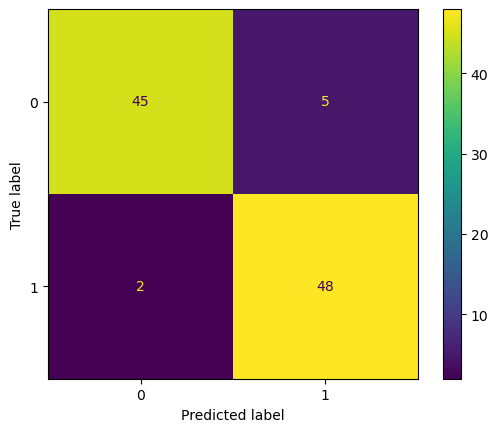

In [16]:
model = SVC(kernel='poly', degree=2) # Try other values of degree
model.fit(X, y)
y_pred = model.predict(X)
print("Accuracy score: ", accuracy_score(y, y_pred))
print("F1 score: ", f1_score(y, y_pred))
ConfusionMatrixDisplay.from_predictions(y, y_pred);

**Plot Decision Boundry for Visualizing Results** 

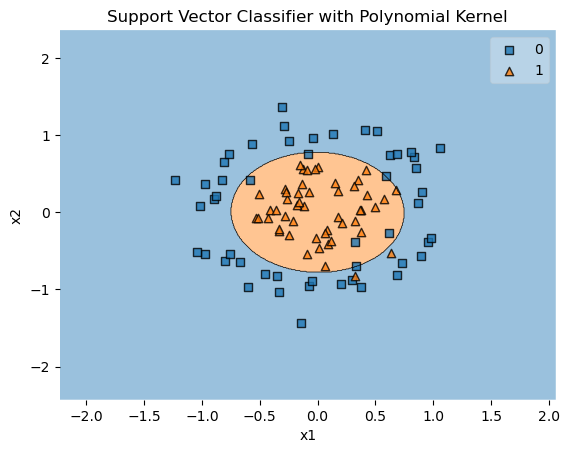

In [17]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X=X, y=y, clf=model)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Support Vector Classifier with Polynomial Kernel')
plt.show();

## c. SVC Radio Basis Function Kernel
<font face = "Courier New" color=magenta size=5>
$\hspace{6cm}K(\overrightarrow{x}, \overrightarrow{l^i}) \hspace{0.5cm}=\hspace{0.5cm} e^{- \gamma \lVert x-l^i \rVert ^2} \hspace{0.5cm}=\hspace{0.5cm} e^{-\frac{\lVert x-l^i \rVert ^2}{2\sigma^2}}$
</font>

- A small value of  𝛾 will lower/flatten the peak of the curve and the data points that are even far away from the landmark point will be considered similar.
- A large value of  𝛾 will raise the peak of the curve and the data points that are very close to thelandmark point will be considered similar.

**Train the Model, Predict and Evaluate** 

Accuracy score:  0.99
F1 score:  0.98989898989899


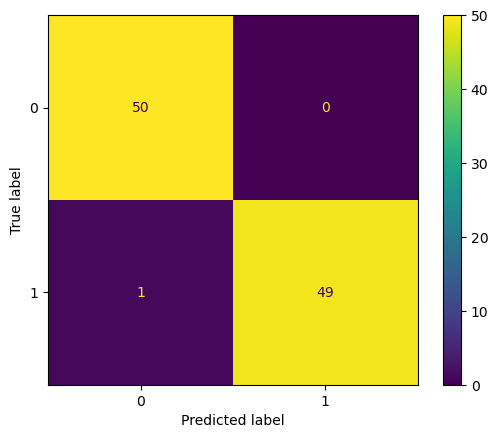

In [20]:
model = SVC(kernel='rbf', gamma=50) 
#model = SVC(kernel='rbf', gamma=50)

model.fit(X, y)
y_pred = model.predict(X)
print("Accuracy score: ", accuracy_score(y, y_pred))
print("F1 score: ", f1_score(y, y_pred))
ConfusionMatrixDisplay.from_predictions(y, y_pred);

**Plot Decision Boundry for Visualizing Results** 

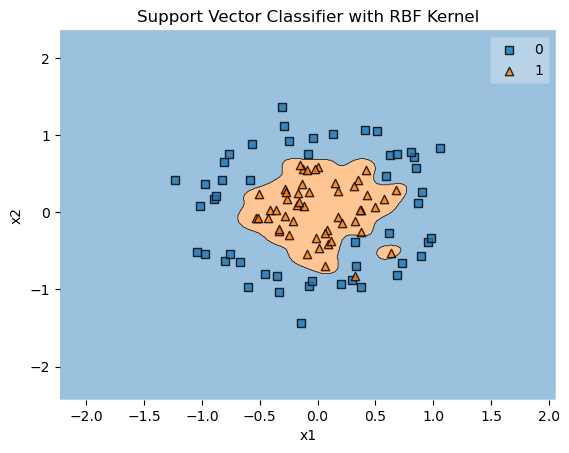

In [21]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X=X, y=y, clf=model)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Support Vector Classifier with RBF Kernel')
plt.show();

# Tasks To Do 

## a. Purchase User-Data

In [22]:
df=pd.read_csv('datasets/User_Data.csv')
df

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


## b. Cancer-Genes

   gene1  gene2  cancer
0    4.3    3.9       1
1    2.5    6.3       0
2    5.7    3.9       1
3    6.1    6.2       0
4    7.4    3.4       1


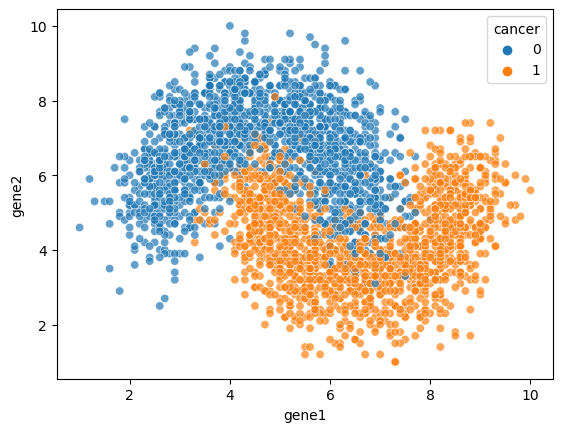

In [23]:
df = pd.read_csv('datasets/gene_expression.csv')
print(df.head())
sns.scatterplot(x='gene1',y='gene2',hue='cancer',data=df,alpha=0.7);

## c. Digit Classification

In [ ]:
digits = datasets.load_digits()
df = pd.DataFrame(digits.data, columns=digits.feature_names)
df['target'] = digits.target
df.head()

<img src="images/pca_digits.png" style="width: 900px;"/>